Analía Olivero Betancor

# Capítulo 4: Firma de Anillos (Ring Signatures)

Este cuaderno recopila las simulaciones utilizadas para analizar la vulnerabilidad histórica del protocolo de Monero originada por la libre elección del tamaño del anillo ($n$). 

## Vulnerabilidad histórica: El ataque de reacción en cadena

En el capítulo $4$ modelamos el protocolo mediante un grafo dirigido $G = (V, E)$ bipartito y acíclico. El conjunto de vértices se divide en monedas ($\mathcal{O}$) y transacciones ($\mathcal{T}$), mientras que las aristas representan el flujo de capital a lo largo del tiempo.

El siguiente código genera una simulación de este grafo. Para recrear las condiciones originales de la red, modelamos $80$ transacciones donde los usuarios eligen un tamaño de anillo $n \in \{1, 4, 7\}$. Si un usuario decide ocultar su gasto ($n > 1$), los $n-1$ señuelos se seleccionan mediante una distribución uniforme sobre todo el conjunto de monedas generadas previamente.

In [1]:
import networkx as nx
import numpy as np
import random

# Fijamos las semillas
random.seed(42)
np.random.seed(42)

# Construimos un grafo dirigido acíclico que simula el flujo de transacciones en Monero.
def generar_grafo_monero(num_txs, tamanos_n):
    G = nx.DiGraph()
    
    monedas_totales = []
    monedas_no_gastadas = []
    
    # Estado inicial: generamos un conjunto de monedas base
    max_n = max(tamanos_n)
    for i in range(max_n * 3):
        id_moneda = f"O_{i}"
        G.add_node(id_moneda, tipo='moneda')
        monedas_totales.append(id_moneda)
        monedas_no_gastadas.append(id_moneda)
        
    contador_monedas = len(monedas_totales)
    
    # Generación cronológica de las transacciones
    for j in range(num_txs):
        id_tx = f"T_{j}"
        
        # El usuario selecciona el tamaño del anillo para esta transacción
        n_actual = random.choice(tamanos_n)
        G.add_node(id_tx, tipo='tx', n_anillo=n_actual)
        
        # Seleccionamos el gasto real (arista principal que consume la moneda)
        gasto_real = random.choice(monedas_no_gastadas)
        monedas_no_gastadas.remove(gasto_real)
        G.add_edge(gasto_real, id_tx, real=True)
        
        # Si el usuario oculta el gasto, introducimos los señuelos
        if n_actual > 1:
            # Los candidatos a señuelo son todas las monedas existentes menos la que se gasta realmente
            candidatos = [m for m in monedas_totales if m != gasto_real]
            senuelos = random.sample(candidatos, n_actual - 1)
            for s in senuelos:
                G.add_edge(s, id_tx, real=False)
                
        # Creación de la nueva moneda de salida generada por la transacción
        nueva_moneda = f"O_{contador_monedas}"
        G.add_node(nueva_moneda, tipo='moneda')
        G.add_edge(id_tx, nueva_moneda)
        
        # Registramos la nueva moneda en el sistema
        monedas_totales.append(nueva_moneda)
        monedas_no_gastadas.append(nueva_moneda)
        contador_monedas += 1
        
    return G, monedas_totales, [f"T_{j}" for j in range(num_txs)]

# Parámetros
n_permitidos = [1, 4, 7]
num_transacciones = 80

# Construcción del modelo
G, lista_monedas, lista_txs = generar_grafo_monero(num_transacciones, n_permitidos)

print(f"Nodos totales (|V|): {G.number_of_nodes()}")
print(f"Aristas totales (|E|): {G.number_of_edges()}\n")

distribucion_n = {1: 0, 4: 0, 7: 0}
for tx in lista_txs:
    n_tx = G.nodes[tx]['n_anillo']
    distribucion_n[n_tx] += 1

print("Distribución del tamaño del anillo elegido en la simulación:")
print(f"  - n=1 (Públicas, 0 señuelos): {distribucion_n[1]} transacciones")
print(f"  - n=4 (Ocultas, 3 señuelos):  {distribucion_n[4]} transacciones")
print(f"  - n=7 (Ocultas, 6 señuelos):  {distribucion_n[7]} transacciones")

Nodos totales (|V|): 181
Aristas totales (|E|): 403

Distribución del tamaño del anillo elegido en la simulación:
  - n=1 (Públicas, 0 señuelos): 27 transacciones
  - n=4 (Ocultas, 3 señuelos):  25 transacciones
  - n=7 (Ocultas, 6 señuelos):  28 transacciones


Una vez construido el grafo $\mathcal{G}$, lo representamos visualmente. Para evidenciar su propiedad de grafo acíclico dirigido, calculamos las generaciones de la red y ordenamos los nodos en columnas. Esto simula el avance temporal mediante la altura de bloque, demostrando que ninguna arista retrocede en el tiempo.

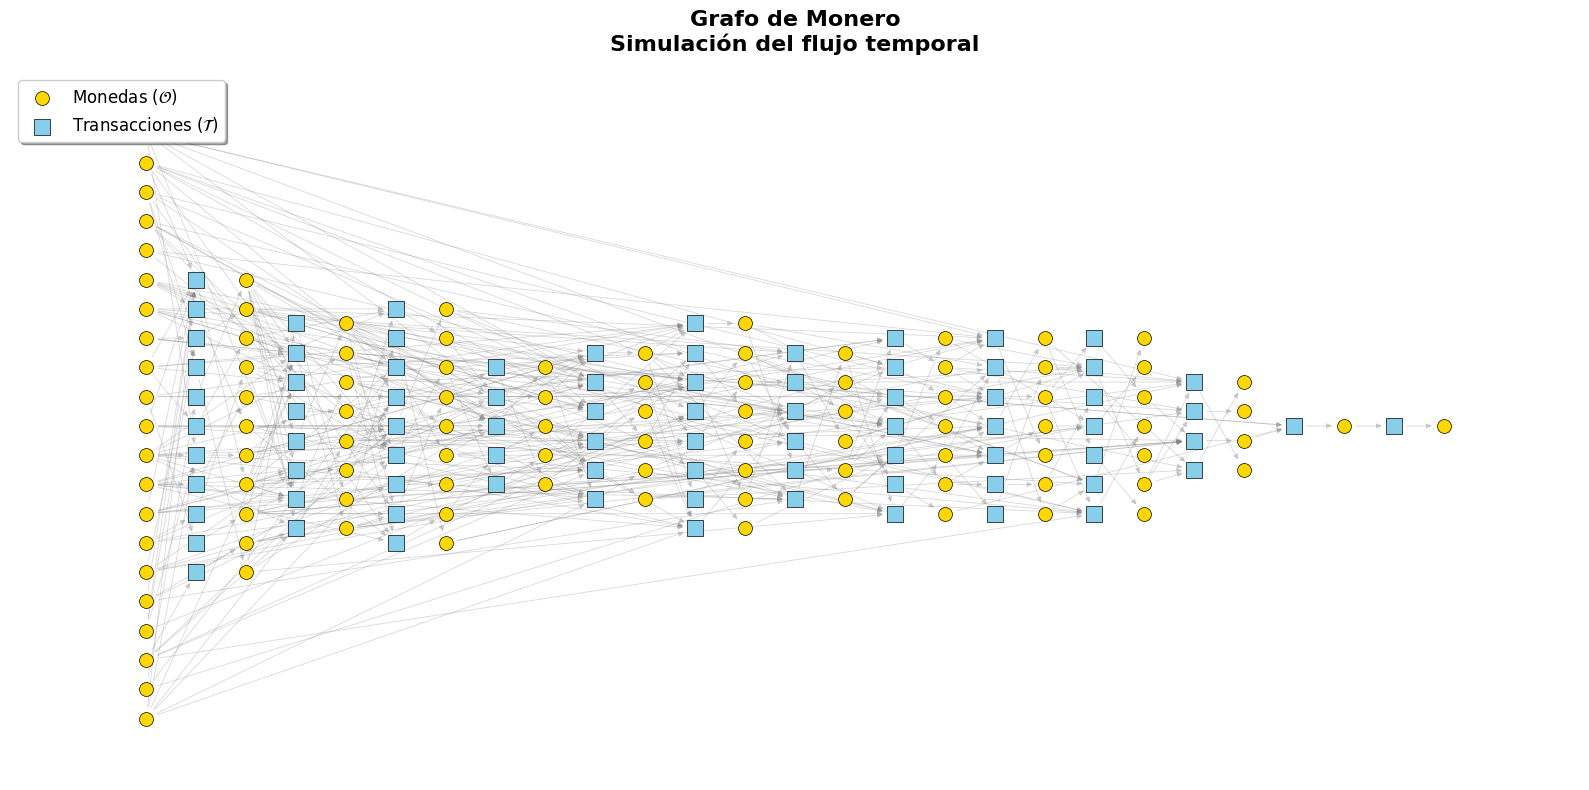

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Calculamos las generaciones para estructurar nuestro eje temporal
for capa, nodos in enumerate(nx.topological_generations(G)):
    for nodo in nodos:
        G.nodes[nodo]["capa_temporal"] = capa 

# Forzamos la alineación vertical por capas
posiciones = nx.multipartite_layout(G, subset_key="capa_temporal", align="vertical")

# Separamos el conjunto V en O (monedas) y T (transacciones) 
nodos_tx = [n for n, attr in G.nodes(data=True) if attr.get('tipo') == 'tx']
nodos_moneda = [n for n, attr in G.nodes(data=True) if attr.get('tipo') == 'moneda']

nx.draw_networkx_nodes(G, posiciones, nodelist=nodos_moneda, node_color='gold', 
                       node_shape='o', node_size=100, edgecolors='black', 
                       linewidths=0.5, label=r'Monedas ($\mathcal{O}$)')

nx.draw_networkx_nodes(G, posiciones, nodelist=nodos_tx, node_color='skyblue', 
                       node_shape='s', node_size=120, edgecolors='black', 
                       linewidths=0.5, label=r'Transacciones ($\mathcal{T}$)')

# Representamos el flujo temporal (aristas)
nx.draw_networkx_edges(G, posiciones, edge_color='gray', arrows=True, 
                       arrowsize=8, alpha=0.3, width=0.6)

plt.title("Grafo de Monero\nSimulación del flujo temporal", fontsize=16, fontweight='bold', pad=15)
plt.legend(scatterpoints=1, frameon=True, shadow=True, loc='upper left', fontsize=12)
plt.axis('off')
plt.tight_layout()

plt.show()

A partir de este grafo simulado, construimos la matriz de probabilidades $W$ de tamaño $|\mathcal{O}| \times |\mathcal{T}|$. Inicialmente aplicamos el Principio de Laplace, asignando la probabilidad uniforme $W_{i,j} = \frac{1}{n}$ a cada candidato del anillo en una transacción. 

El siguiente código implementa el algoritmo iterativo de deducción. El proceso busca certezas absolutas ($W_{i,j} = 1$) que se corresponden con los usuarios que fijaron $n=1$. Cuando encuentra una certeza, elimina esa moneda de cualquier otro anillo donde estuviera actuando como señuelo, forzando a redistribuir la probabilidad entre los candidatos supervivientes y generando la reacción en cadena.

In [3]:
import numpy as np

# Construcción de la matriz de probabilidades inicial (W)
num_monedas = len(lista_monedas)
num_txs = len(lista_txs)

W = np.zeros((num_monedas, num_txs))

idx_moneda = {m: i for i, m in enumerate(lista_monedas)}
idx_tx = {t: j for j, t in enumerate(lista_txs)}

for id_tx in lista_txs:
    j = idx_tx[id_tx]
    predecesores = list(G.predecessors(id_tx))
    n_real = len(predecesores)
    
    if n_real > 0:
        prob_inicial = 1.0 / n_real
        for id_moneda in predecesores:
            i = idx_moneda[id_moneda]
            W[i, j] = prob_inicial

# Ataque de deducción (reacción en cadena)
W_final = np.copy(W)
cambios = True

while cambios:
    cambios = False
    
    # Identificamos las coordenadas donde existe certidumbre absoluta de gasto
    certezas = np.argwhere(W_final == 1.0)
    
    for i, j in certezas:
        # Propagamos el valor 0 en el resto de la fila i para anular su efecto como señuelo
        for k in range(num_txs):
            if k != j and W_final[i, k] > 0:
                W_final[i, k] = 0.0
                cambios = True # Se activa una nueva iteración de la cascada
                
    # Si ha habido cambios, redistribuimos la probabilidad en los anillos afectados
    if cambios:
        for k in range(num_txs):
            candidatos_vivos = np.where(W_final[:, k] > 0)[0]
            candidatos_iniciales = np.where(W[:, k] > 0)[0]
            
            # El anillo ha perdido señuelos pero aún no es una certeza
            if 0 < len(candidatos_vivos) < len(candidatos_iniciales):
                nueva_prob = 1.0 / len(candidatos_vivos)
                for idx in candidatos_vivos:
                    if W_final[idx, k] != nueva_prob:
                        W_final[idx, k] = nueva_prob

# Evaluación del impacto del ataque
txs_expuestas_inicio = np.sum(np.max(W, axis=0) == 1.0)
txs_expuestas_fin = np.sum(np.max(W_final, axis=0) == 1.0)

print(f"Transacciones totalmente expuestas de forma nativa (n=1): {txs_expuestas_inicio}")
print(f"Transacciones comprometidas tras el efecto cascada del ataque: {txs_expuestas_fin}")

Transacciones totalmente expuestas de forma nativa (n=1): 27
Transacciones comprometidas tras el efecto cascada del ataque: 27


Para evaluar visualmente el impacto de la contaminación de la red y la pérdida del anonimato, graficamos los resultados. Primero, representamos la evolución de la matriz $W$ mediante un mapa de calor para evidenciar la propagación de certezas en su estructura triangular. Posteriormente, calculamos la reducción del tamaño de anillo ($n$) que han sufrido las transacciones de forma colateral a causa del comportamiento del resto de usuarios.

<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

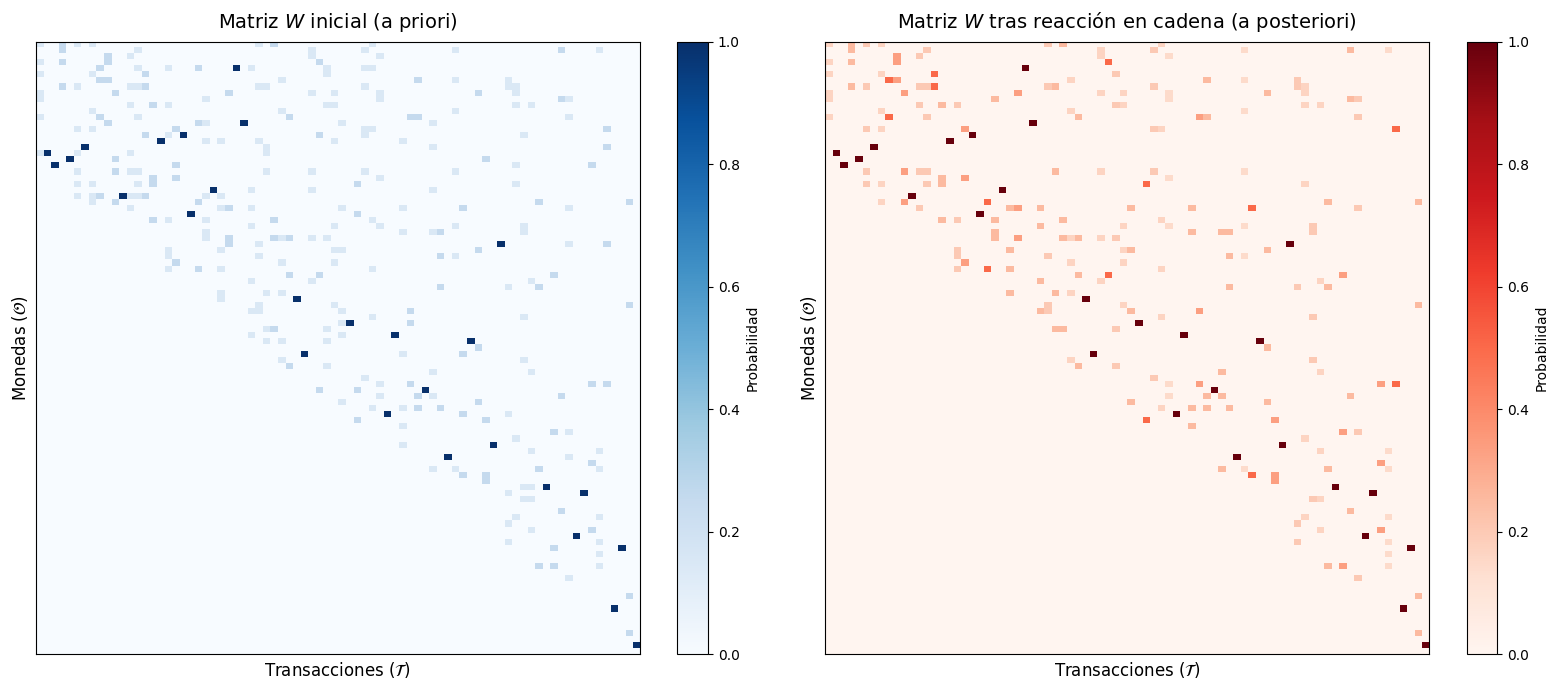

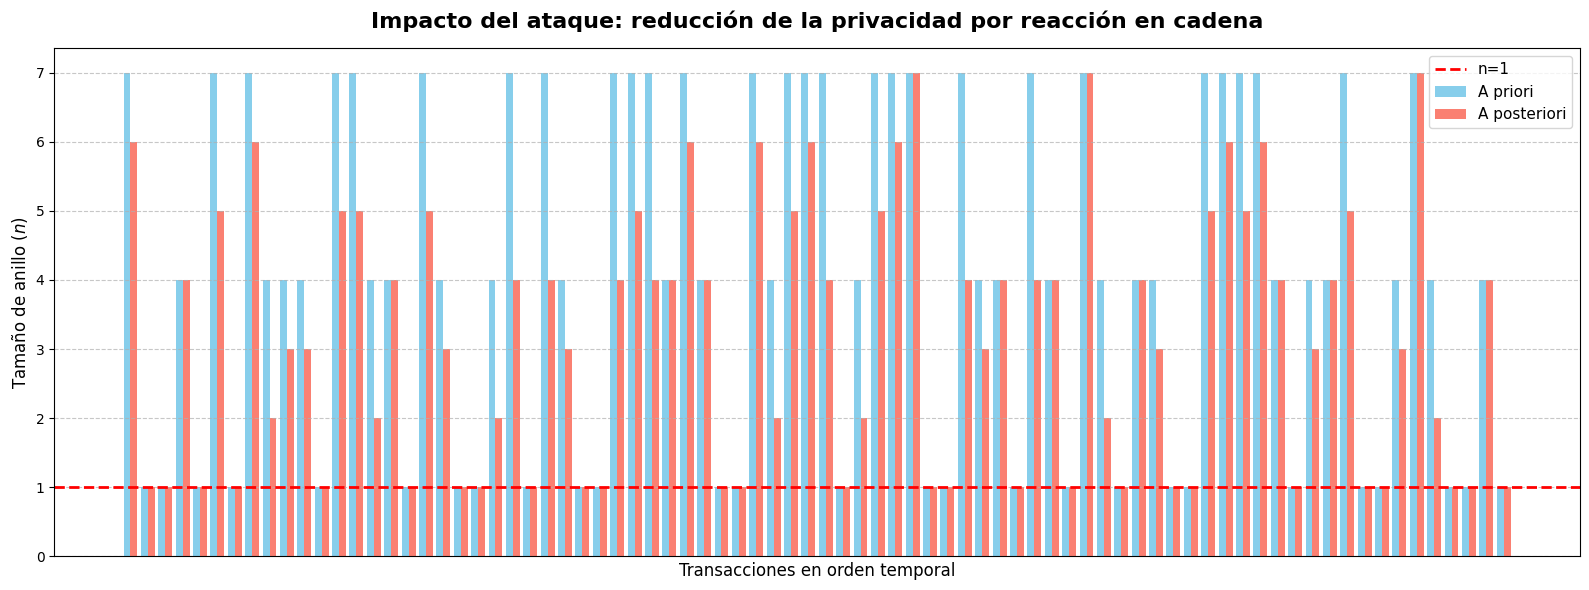

In [ ]:
import matplotlib.pyplot as plt


# Figura 1: mapas de calor
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# W inicial (azul)
cax1 = axes[0].imshow(W, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Matriz $W$ inicial (a priori)', fontsize=14, pad=10)
axes[0].set_xlabel('Transacciones ($\mathcal{T}$)', fontsize=12)
axes[0].set_ylabel('Monedas ($\mathcal{O}$)', fontsize=12)
axes[0].set_xticks([]) 
axes[0].set_yticks([]) 
fig.colorbar(cax1, ax=axes[0], label='Probabilidad')

# W tras la reacción en cadena (rojo)
cax2 = axes[1].imshow(W_final, cmap='Reds', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Matriz $W$ tras reacción en cadena (a posteriori)', fontsize=14, pad=10)
axes[1].set_xlabel('Transacciones ($\mathcal{T}$)', fontsize=12)
axes[1].set_ylabel('Monedas ($\mathcal{O}$)', fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(cax2, ax=axes[1], label='Probabilidad')
plt.tight_layout()

plt.show()


# Figura 2: reducción del tamaño del anillo
anillos_iniciales = np.sum(W > 0, axis=0)
anillos_finales = np.sum(W_final > 0, axis=0)

x = np.arange(num_txs)
ancho_barra = 0.4 

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - ancho_barra/2, anillos_iniciales, ancho_barra, label='A priori', color='skyblue')
ax.bar(x + ancho_barra/2, anillos_finales, ancho_barra, label='A posteriori', color='salmon')

ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='n=1')

ax.set_ylabel('Tamaño de anillo ($n$)', fontsize=12)
ax.set_xlabel('Transacciones en orden temporal', fontsize=12)
ax.set_title('Impacto del ataque: reducción de la privacidad por reacción en cadena', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks([]) 
ax.set_yticks(np.arange(0, max(anillos_iniciales) + 1, 1))
ax.legend(fontsize=11, loc='upper right')

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)
plt.tight_layout()

plt.show()